# 实战 Case 7: VoC 体验诊断 — 电商评论文本挖掘 🔍

> **商业背景**: 你是某跨境电商客服体验分析师，日均 2M+ 会话中转人工率 37%，需要从用户差评/低分评论中
> 定位核心痛点，推动产研修复，降低转人工率。
>
> **分析目标**: 建立 VoC（Voice of Customer）诊断体系，通过文本挖掘识别 Top 痛点，
> 做交叉分析定位根因，输出可执行的优先级排序。

## 📋 本次实战覆盖的面试高频考点

| 考点 | 对应步骤 | 面试常见问法 |
| :--- | :--- | :--- |
| 文本预处理 | Step 1-2 | "你怎么处理多语种文本？" |
| TF-IDF 高频词提取 | Step 3 | "TF-IDF 和 WordCount 有什么区别？" |
| 主题聚类 (LDA) | Step 4 | "你怎么发现隐藏的痛点主题？" |
| 交叉分析 | Step 5 | "你怎么定位是哪个市场/品类的问题？" |
| YoY 异常检测 | Step 6 | "怎么区分周期性问题和新增恶化？" |
| 优先级排序 | Step 7 | "资源有限时怎么决定先修哪个？" |

---

## ⛽ 模块 0: 函数加油站 (Function Cheat Sheet)

| 函数 | 大白话 | SQL 类比 |
| :--- | :--- | :--- |
| `TfidfVectorizer()` | 把文本转成"重要词权重矩阵" | 无直接类比，但类似 COUNT + 权重 |
| `CountVectorizer()` | 把文本转成"词频矩阵" | `GROUP BY word ORDER BY COUNT(*) DESC` |
| `LatentDirichletAllocation()` | 自动发现文本里隐藏的主题 | 类似无监督的 `CASE WHEN` 分类 |
| `nltk.word_tokenize()` | 英文分词 | `SPLIT(text, ' ')` |
| `nltk.corpus.stopwords` | 停用词表（the, is, a 等无意义词） | `WHERE word NOT IN ('the','is','a')` |
| `WordNetLemmatizer()` | 词形还原（running → run） | 无直接类比 |
| `pd.crosstab()` | 交叉列联表 | `SELECT a, b, COUNT(*) GROUP BY a, b` |

## Step 0: 环境准备 & 数据导入

In [14]:
# 数据导入 (Kaggle API)
# 强制使用绝对路径调用 kaggle
# !kaggle datasets download nicapotato/womens-ecommerce-clothing-reviews --path ./data --unzip -f 'Womens Clothing E-Commerce Reviews.csv'

In [15]:
# ============================================================
# 依赖包安装（首次运行需要）
# ============================================================
# !pip install nltk scikit-learn -q

In [16]:
# ============================================================
# 环境配置
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP 工具
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 中文字体配置
import platform
if platform.system() == 'Darwin':
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
else:
    plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# Seaborn 主题
sns.set_theme(style='whitegrid', palette='muted')

print('✅ 环境配置完成！')

✅ 环境配置完成！


In [17]:
# ============================================================
# 加载数据
# 注意: Kaggle 下载的文件名空格被编码为 %20
# ============================================================
import os
DATA_DIR = './data'
# 自动检测文件名（兼容空格和%20两种情况）
candidates = [
    'Womens Clothing E-Commerce Reviews.csv',
    'Womens%20Clothing%20E-Commerce%20Reviews.csv',
]
data_path = None
for name in candidates:
    path = os.path.join(DATA_DIR, name)
    if os.path.exists(path):
        data_path = path
        break
if data_path is None:
    raise FileNotFoundError(f'数据文件未找到，请检查 {DATA_DIR} 目录')

df = pd.read_csv(data_path, index_col=0)
print(f'📊 数据集大小: {df.shape}')
print(f'📊 列名: {list(df.columns)}')
df.head()

📊 数据集大小: (23486, 10)
📊 列名: ['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


## Step 1: 数据探索 & 理解业务语境

> **面试映射**: "我首先对数据做 EDA，了解评分分布、品类分布、文本长度分布，
> 确定分析的粒度和范围。"

In [18]:
# ============================================================
# 1.1 数据概览
# ============================================================
print('='*60)
print('📋 数据概览')
print('='*60)
print(f'\n总记录数: {len(df):,}')
print(f'\n缺失值统计:')
print(df.isnull().sum())
print(f'\n数据类型:')
print(df.dtypes)

📋 数据概览

总记录数: 23,486

缺失值统计:
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

数据类型:
Clothing ID                int64
Age                        int64
Title                        str
Review Text                  str
Rating                     int64
Recommended IND            int64
Positive Feedback Count    int64
Division Name                str
Department Name              str
Class Name                   str
dtype: object


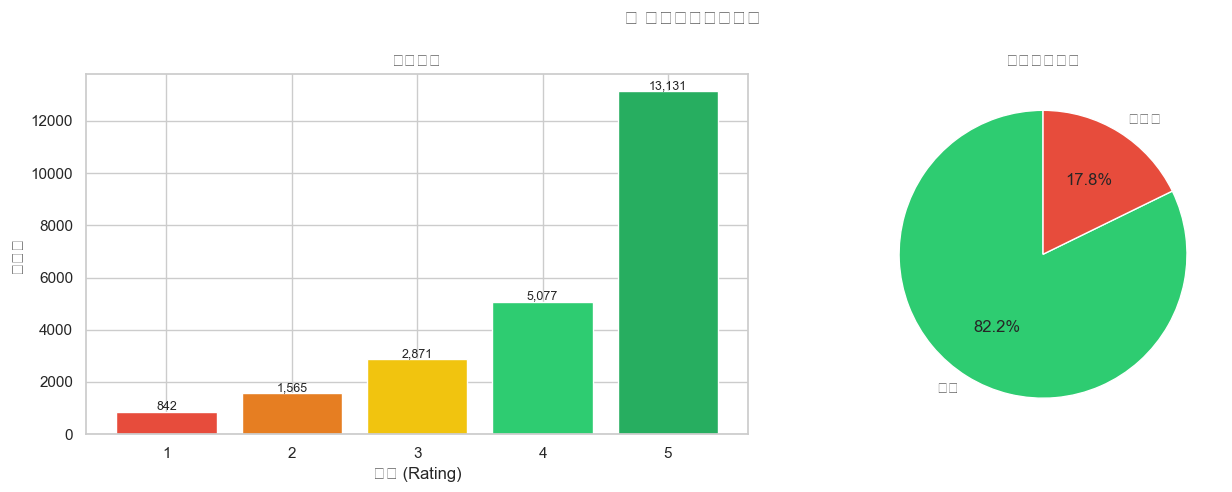


🔴 差评定义: Rating ≤ 2
🔴 差评数量: 2,407 / 23,486 (10.2%)


In [19]:
# ============================================================
# 1.2 评分分布 — 确定"差评"的阈值
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 评分分布
rating_counts = df['Rating'].value_counts().sort_index()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
axes[0].bar(rating_counts.index, rating_counts.values, color=colors)
axes[0].set_xlabel('评分 (Rating)')
axes[0].set_ylabel('评论数')
axes[0].set_title('评分分布')
for i, v in enumerate(rating_counts.values):
    axes[0].text(rating_counts.index[i], v + 100, f'{v:,}', ha='center', fontsize=9)

# 是否推荐分布
recommend_counts = df['Recommended IND'].value_counts()
axes[1].pie(recommend_counts.values, labels=['推荐', '不推荐'], 
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('用户是否推荐')

plt.suptitle('📊 用户评价整体画像', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 定义差评 = 评分 1-2
NEGATIVE_THRESHOLD = 2
print(f'\n🔴 差评定义: Rating ≤ {NEGATIVE_THRESHOLD}')
print(f'🔴 差评数量: {(df["Rating"] <= NEGATIVE_THRESHOLD).sum():,} / {len(df):,} ({(df["Rating"] <= NEGATIVE_THRESHOLD).mean():.1%})')

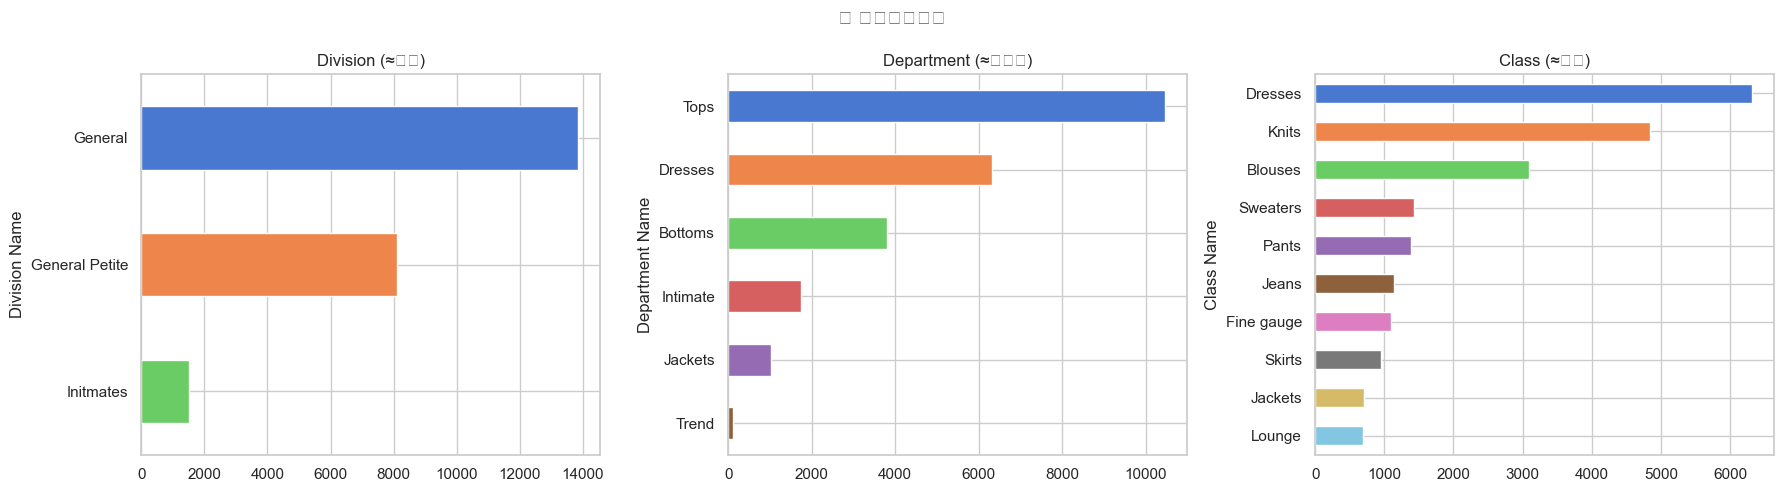

In [20]:
# ============================================================
# 1.3 品类分布 — 了解业务结构
# 类比 某跨境电商S公司: Division = 市场, Department = 业务线, Class = 品类
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(axes, 
    ['Division Name', 'Department Name', 'Class Name'],
    ['Division (≈市场)', 'Department (≈业务线)', 'Class (≈品类)']):
    counts = df[col].value_counts().head(10)
    counts.plot.barh(ax=ax, color=sns.color_palette('muted', len(counts)))
    ax.set_title(title)
    ax.invert_yaxis()

plt.suptitle('📦 品类结构分布', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 2: 文本预处理

> **面试映射**: "文本预处理包括分词、去停用词、词形还原。在 某跨境电商S公司 多语种场景下，
> 我们先统一翻译成英语再做文本分析，因为维护多语种分词管道成本太高。"

### 预处理流程
```
原始文本 → 转小写 → 分词 → 去停用词 → 词形还原 → 清洁文本
```

In [ ]:
# ============================================================
# 2.1 构建文本预处理管道
# ============================================================
lemmatizer = WordNetLemmatizer() # 词形还原器 running > run
stop_words = set(stopwords.words('english')) # 加载英文停用词表

# 添加业务自定义停用词（电商场景高频但无意义的词）
CUSTOM_STOPWORDS = {
    'dress', 'top', 'wear', 'would', 'like', 'one', 'also',
    'really', 'look', 'get', 'got', 'go', 'make', 'made',
    'much', 'even', 'still', 'try', 'tried', 'could',
}
stop_words = stop_words.union(CUSTOM_STOPWORDS)


def preprocess_text(text: str) -> str:
    """文本预处理管道
    
    Args:
        text: 原始评论文本
    Returns:
        清洁后的文本（空格分隔的词序列）
    """
    if pd.isna(text):
        return ''
    
    # 转小写
    text = text.lower()
    
    # 分词
    tokens = word_tokenize(text)
    
    # 只保留字母组成的词 + 去停用词 + 词形还原
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token.isalpha() and token not in stop_words and len(token) > 2
    ]
    
    return ' '.join(tokens)


# 测试预处理效果
sample_text = df['Review Text'].dropna().iloc[0]
print(f'原始文本: {sample_text[:200]}')
print(f'\n处理后: {preprocess_text(sample_text)}')

原始文本: Absolutely wonderful - silky and sexy and comfortable

处理后: absolutely wonderful silky sexy comfortable


In [22]:
# ============================================================
# 2.2 批量预处理 — 只处理有文本的行
# ============================================================
# 过滤：只保留有评论文本的行
df_text = df.dropna(subset=['Review Text']).copy()
print(f'有文本的评论: {len(df_text):,} / {len(df):,}')

# 批量处理
df_text['clean_text'] = df_text['Review Text'].apply(preprocess_text)

# 过滤空文本
df_text = df_text[df_text['clean_text'].str.strip() != ''].copy()
print(f'处理后有效文本: {len(df_text):,}')

# 添加标签
df_text['is_negative'] = (df_text['Rating'] <= NEGATIVE_THRESHOLD).astype(int)
print(f'\n差评占比: {df_text["is_negative"].mean():.2%}')

df_text[['Review Text', 'clean_text', 'Rating', 'is_negative']].head()

有文本的评论: 22,641 / 23,486
处理后有效文本: 22,641

差评占比: 10.47%


,Review Text,clean_text,Rating,is_negative
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky sexy comfortable,4,0
1,Love this dress! it's sooo pretty. i happene...,love sooo pretty happened find store glad neve...,5,0
2,I had such high hopes for this dress and reall...,high hope wanted work initially ordered petite...,3,0
3,"I love, love, love this jumpsuit. it's fun, fl...",love love love jumpsuit fun flirty fabulous ev...,5,0
4,This shirt is very flattering to all due to th...,shirt flattering due adjustable front tie perf...,5,0


## Step 3: TF-IDF 高频词提取 — 定位痛点关键词

> **面试映射**: "TF-IDF 比简单词频更好，因为它会降低所有文档中都出现的
> 通用词（如 shipping、order）的权重，突出真正能区分痛点的关键词。"

### TF-IDF 公式直觉
$$TF\text{-}IDF(t, d) = TF(t, d) \times \log\frac{N}{DF(t)}$$

- **TF**: 这个词在当前文档中出现得多 → 对这篇文档重要
- **IDF**: 这个词在全部文档中出现得少 → 区分度高

In [34]:
# ============================================================
# 3.1 差评 vs 好评的高频词对比
# ============================================================
# 分别提取差评和好评的文本
negative_texts = df_text[df_text['is_negative'] == 1]['clean_text']
positive_texts = df_text[df_text['is_negative'] == 0]['clean_text']

print(f'差评文本数: {len(negative_texts):,}')
print(f'好评文本数: {len(positive_texts):,}')

# TF-IDF 配置
TFIDF_MAX_FEATURES = 500  # 最多保留 500 个特征词
TFIDF_NGRAM_RANGE = (1, 2)  # 支持单词和双词组合
TFIDF_MIN_DF = 5  # 至少出现在 5 篇文档中

tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM_RANGE,
    min_df=TFIDF_MIN_DF,
)

# 分别对差评和好评做 TF-IDF
tfidf_neg = tfidf.fit_transform(negative_texts)
neg_feature_names = tfidf.get_feature_names_out()
neg_scores = tfidf_neg.mean(axis=0).A1  # 取平均 TF-IDF 分数
neg_top = pd.Series(neg_scores, index=neg_feature_names).sort_values(ascending=False)

tfidf_pos = tfidf.fit_transform(positive_texts)
pos_feature_names = tfidf.get_feature_names_out()
pos_scores = tfidf_pos.mean(axis=0).A1
pos_top = pd.Series(pos_scores, index=pos_feature_names).sort_values(ascending=False)

print('\n🔴 差评 Top 15 关键词:')
print(neg_top.head(15))
print('\n🟢 好评 Top 15 关键词:')
print(pos_top.head(15))

差评文本数: 2,370
好评文本数: 20,271

🔴 差评 Top 15 关键词:
fabric      0.040851
size        0.039448
fit         0.039384
back        0.035080
color       0.032739
shirt       0.030934
small       0.030219
material    0.029338
love        0.028996
ordered     0.028693
look        0.027648
looked      0.026213
way         0.025837
quality     0.024025
cute        0.023100
dtype: float64

🟢 好评 Top 15 关键词:
love           0.051015
fit            0.049102
size           0.046785
great          0.041244
color          0.039972
fabric         0.029627
small          0.028890
perfect        0.028759
little         0.027149
comfortable    0.026898
flattering     0.026809
soft           0.025774
cute           0.025089
ordered        0.024606
beautiful      0.024311
dtype: float64


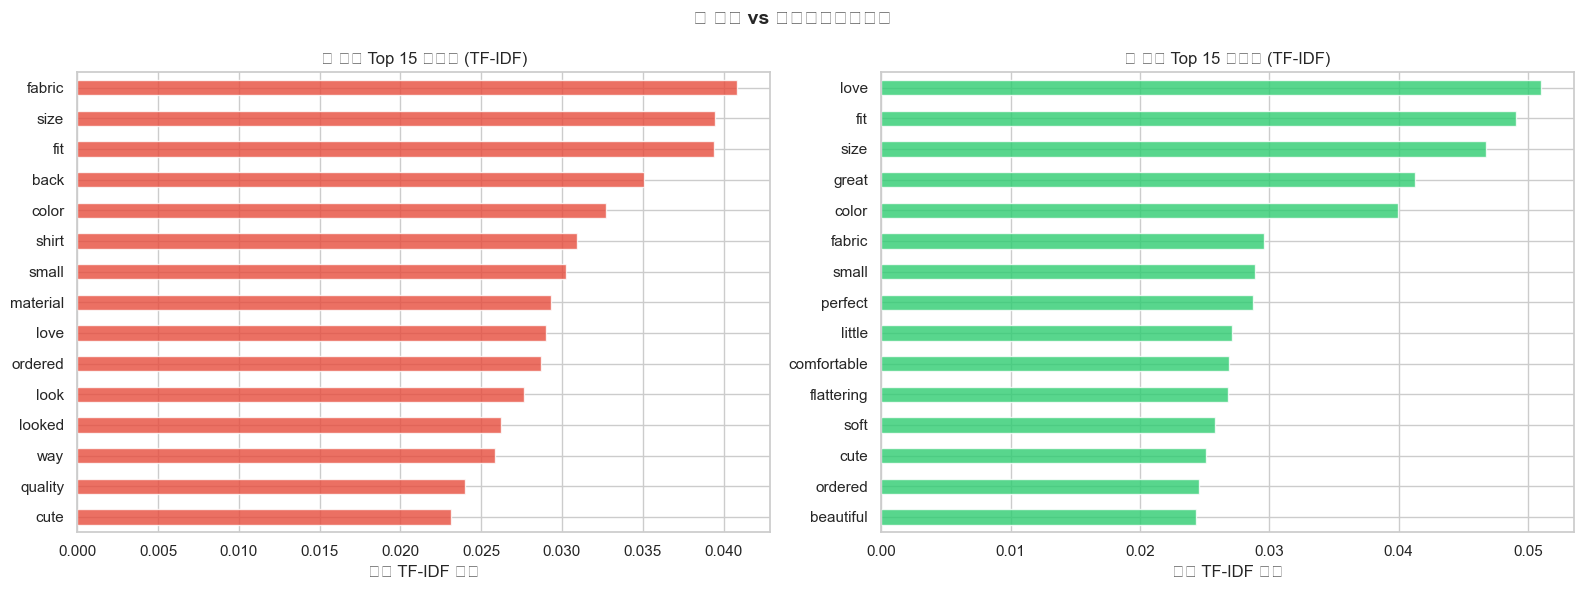

In [24]:
# ============================================================
# 3.2 可视化: 差评 vs 好评关键词对比
# ============================================================
TOP_N = 15

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 差评关键词
neg_top.head(TOP_N).sort_values().plot.barh(
    ax=axes[0], color='#e74c3c', alpha=0.8
)
axes[0].set_title(f'🔴 差评 Top {TOP_N} 关键词 (TF-IDF)', fontsize=12)
axes[0].set_xlabel('平均 TF-IDF 分数')

# 好评关键词
pos_top.head(TOP_N).sort_values().plot.barh(
    ax=axes[1], color='#2ecc71', alpha=0.8
)
axes[1].set_title(f'🟢 好评 Top {TOP_N} 关键词 (TF-IDF)', fontsize=12)
axes[1].set_xlabel('平均 TF-IDF 分数')

plt.suptitle('📊 差评 vs 好评的关键词差异', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: 主题聚类 (LDA) — 发现隐藏的痛点主题

> **面试映射**: "高频词能告诉你哪些词出现多，但不能告诉你这些词的组合代表什么业务痛点。
> LDA 主题模型能自动将差评聚类成几个主题，比如'尺码问题'、'面料质量'、'物流延误'。"

### LDA 直觉
- 每篇文档 = 多个主题的混合
- 每个主题 = 多个词的概率分布
- LDA 自动学习：哪些词经常一起出现 → 同一个主题

In [25]:
# ============================================================
# 4.1 对差评做 LDA 主题模型
# ============================================================
N_TOPICS = 5  # 主题数量（初始设为 5，可调优）
RANDOM_STATE = 42

# LDA 需要 CountVectorizer（词频矩阵），不是 TF-IDF
count_vec = CountVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=TFIDF_MIN_DF,
)
neg_count_matrix = count_vec.fit_transform(negative_texts)

# 训练 LDA
lda = LatentDirichletAllocation(
    n_components=N_TOPICS, 
    random_state=RANDOM_STATE,
    max_iter=20,
    learning_method='online',
)
lda.fit(neg_count_matrix)

# 提取每个主题的 Top 关键词
feature_names = count_vec.get_feature_names_out()
WORDS_PER_TOPIC = 10

print('='*60)
print(f'🔍 LDA 差评主题分析 ({N_TOPICS} 个主题)')
print('='*60)

topic_labels = {}  # 存储主题标签，后续手动命名
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-WORDS_PER_TOPIC-1:-1]]
    print(f'\n📌 Topic {topic_idx}: {" | ".join(top_words)}')
    # 根据关键词手动命名主题（面试时这就是你的"业务判断力"）
    topic_labels[topic_idx] = f'Topic_{topic_idx}'

🔍 LDA 差评主题分析 (5 个主题)

📌 Topic 0: material | quality | fabric | fit | run | color | small | way | size | jean

📌 Topic 1: back | shirt | going | love | look | sweater | going back | looked | wanted | online

📌 Topic 2: time | first | loved | pant | bought | washed | wore | wash | shirt | retailer

📌 Topic 3: size | fit | small | ordered | large | arm | medium | way | fabric | chest

📌 Topic 4: fabric | cheap | color | look | material | looked | back | felt | blouse | photo


In [26]:
# ============================================================
# 4.2 💡 关键步骤: 根据关键词命名主题（需要业务经验！）
# 这一步在面试中非常重要 — 它展示你的"业务判断力"
# ============================================================

# ⚠️ 运行完上面的 LDA 后，根据输出的关键词手动命名：
# TODO: 根据实际 LDA 输出修改以下标签
TOPIC_NAMES = {
    0: '尺码/版型问题',    # 如果看到 size, fit, small, large, tight 等
    1: '面料/质量问题',    # 如果看到 fabric, material, quality, cheap 等
    2: '退货/退款问题',    # 如果看到 return, back, send, refund 等
    3: '价格/性价比问题',  # 如果看到 price, expensive, worth, money 等
    4: '款式/期望落差',    # 如果看到 picture, expected, different, color 等
}

print('📋 主题命名映射:')
for k, v in TOPIC_NAMES.items():
    print(f'  Topic {k} → {v}')

📋 主题命名映射:
  Topic 0 → 尺码/版型问题
  Topic 1 → 面料/质量问题
  Topic 2 → 退货/退款问题
  Topic 3 → 价格/性价比问题
  Topic 4 → 款式/期望落差



📊 差评主题分布:
topic_name
价格/性价比问题    811
面料/质量问题     548
尺码/版型问题     374
款式/期望落差     332
退货/退款问题     305
Name: count, dtype: int64

平均主题置信度: 61.57%


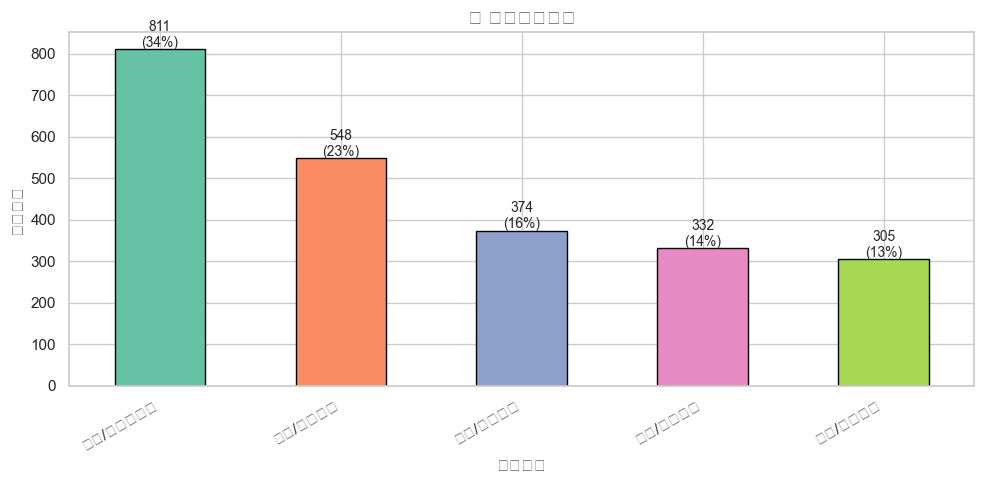

In [27]:
# ============================================================
# 4.3 为每条差评分配主题
# ============================================================
# 计算每条差评在各主题上的概率分布
neg_topic_dist = lda.transform(neg_count_matrix)

# 取概率最高的主题作为该评论的主题
df_neg = df_text[df_text['is_negative'] == 1].copy()
df_neg['topic_id'] = neg_topic_dist.argmax(axis=1)
df_neg['topic_name'] = df_neg['topic_id'].map(TOPIC_NAMES)
df_neg['topic_confidence'] = neg_topic_dist.max(axis=1)

# 主题分布
topic_dist = df_neg['topic_name'].value_counts()
print('\n📊 差评主题分布:')
print(topic_dist)
print(f'\n平均主题置信度: {df_neg["topic_confidence"].mean():.2%}')

# 可视化
fig, ax = plt.subplots(figsize=(10, 5))
topic_dist.plot.bar(ax=ax, color=sns.color_palette('Set2', N_TOPICS), edgecolor='black')
ax.set_title('🔍 差评主题分布', fontsize=14, fontweight='bold')
ax.set_xlabel('痛点主题')
ax.set_ylabel('差评数量')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
for i, v in enumerate(topic_dist.values):
    ax.text(i, v + 5, f'{v}\n({v/len(df_neg):.0%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## Step 5: 交叉分析 — 主题 × 品类/市场

> **面试映射**: "发现痛点主题后，下一步是交叉分析——哪些品类/市场的哪个痛点最严重。
> 这样才能精准推动对应的产品或运营团队修复。"

### 类比 某跨境电商S公司:
- `Division Name` ≈ 市场（中东/欧洲/北美）
- `Department Name` ≈ 业务线（智能客服/人工客服）
- `Class Name` ≈ 场景（物流/退款/尺码）

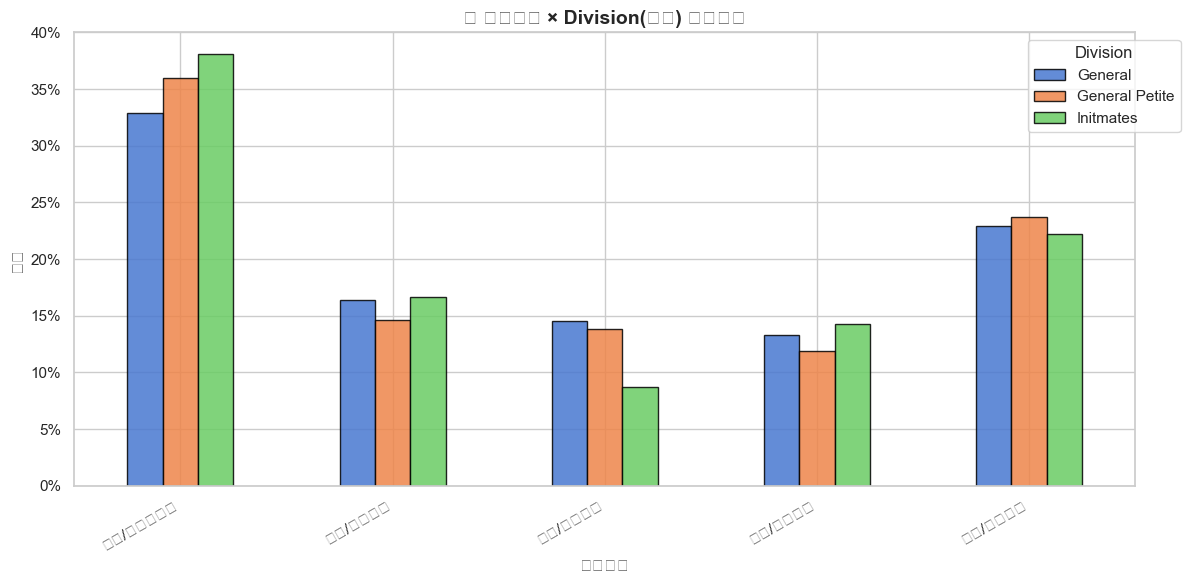


📋 交叉表（占比）:
Division Name  General  General Petite  Initmates
topic_name                                       
价格/性价比问题         0.329           0.360      0.381
尺码/版型问题          0.164           0.146      0.167
款式/期望落差          0.146           0.139      0.087
退货/退款问题          0.133           0.119      0.143
面料/质量问题          0.229           0.237      0.222


In [28]:
# ============================================================
# 5.1 交叉表: 痛点主题 × Division（≈市场）
# ============================================================
cross_division = pd.crosstab(
    df_neg['topic_name'], 
    df_neg['Division Name'],
    normalize='columns'  # 按列归一化 = 每个市场内的主题占比
)

fig, ax = plt.subplots(figsize=(12, 6))
cross_division.plot.bar(ax=ax, stacked=False, edgecolor='black', alpha=0.85)
ax.set_title('📊 痛点主题 × Division(市场) 交叉分析', fontsize=14, fontweight='bold')
ax.set_xlabel('痛点主题')
ax.set_ylabel('占比')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Division', bbox_to_anchor=(1.05, 1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

print('\n📋 交叉表（占比）:')
print(cross_division.round(3))

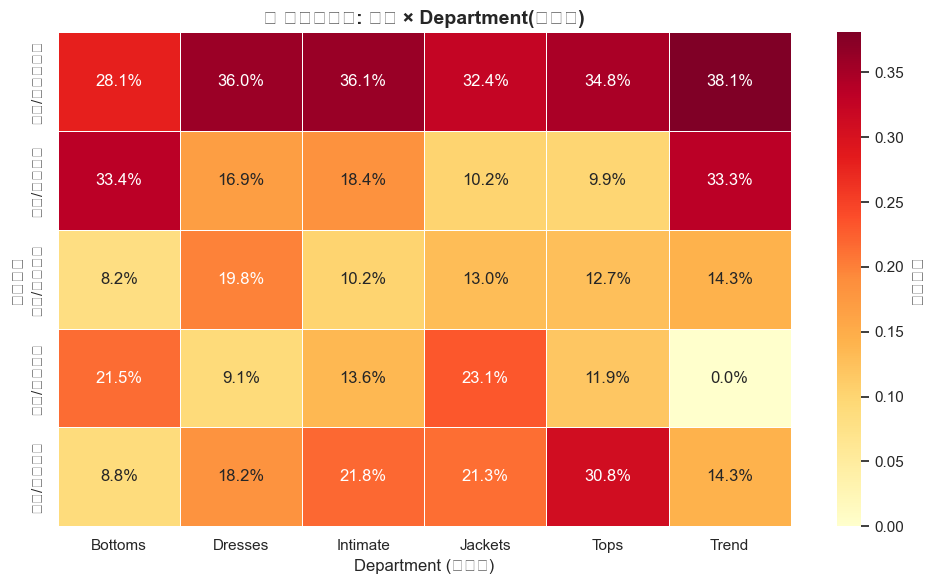


💡 分析洞察: 哪个业务线的哪个痛点最突出？


In [29]:
# ============================================================
# 5.2 交叉表: 痛点主题 × Department（≈业务线）
# ============================================================
cross_dept = pd.crosstab(
    df_neg['topic_name'],
    df_neg['Department Name'],
    normalize='columns'
)

# 用热力图展示
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    cross_dept, annot=True, fmt='.1%', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': '痛点占比'}
)
ax.set_title('🔥 痛点热力图: 主题 × Department(业务线)', fontsize=14, fontweight='bold')
ax.set_xlabel('Department (业务线)')
ax.set_ylabel('痛点主题')
plt.tight_layout()
plt.show()

print('\n💡 分析洞察: 哪个业务线的哪个痛点最突出？')

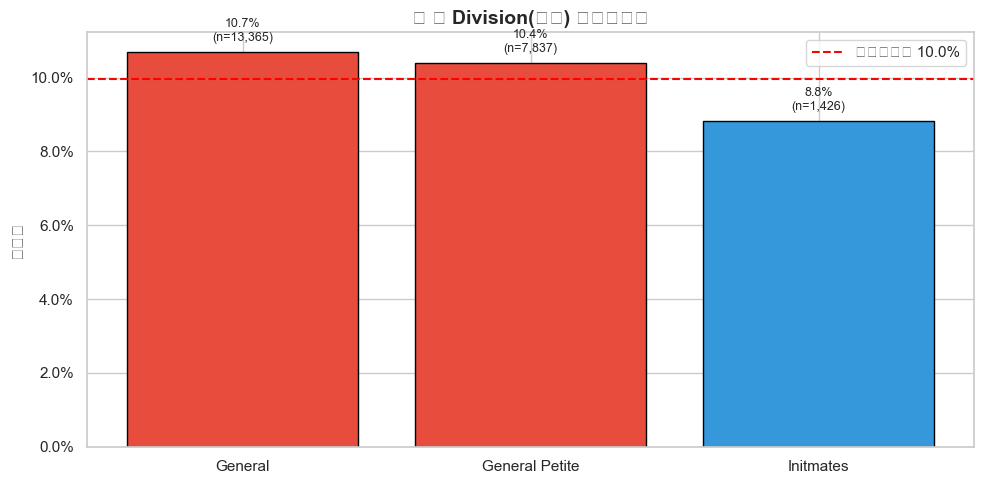

In [30]:
# ============================================================
# 5.3 差评率交叉分析: Division × Rating
# 类比 某跨境电商S公司: 各市场的差评率对比
# ============================================================
neg_rate_by_division = df_text.groupby('Division Name')['is_negative'].agg(['mean', 'count'])
neg_rate_by_division.columns = ['差评率', '评论总数']
neg_rate_by_division = neg_rate_by_division.sort_values('差评率', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    neg_rate_by_division.index, 
    neg_rate_by_division['差评率'],
    color=['#e74c3c' if x > neg_rate_by_division['差评率'].mean() else '#3498db' 
           for x in neg_rate_by_division['差评率']],
    edgecolor='black'
)
ax.axhline(y=neg_rate_by_division['差评率'].mean(), color='red', linestyle='--', 
           label=f'平均差评率 {neg_rate_by_division["差评率"].mean():.1%}')
ax.set_title('📊 各 Division(市场) 差评率对比', fontsize=14, fontweight='bold')
ax.set_ylabel('差评率')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend()
for bar, rate, count in zip(bars, neg_rate_by_division['差评率'], neg_rate_by_division['评论总数']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, 
            f'{rate:.1%}\n(n={count:,})', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Step 6: YoY 模拟分析 — 区分周期性 vs 新增恶化

> **面试映射**: "识别出高频问题后，我需要区分两类：一是每年都会出现的周期性问题（如大促后退货激增），
> 二是今年新涌现或显著恶化的问题。资源应该优先投入到恶化类问题上。"

⚠️ 数据集没有时间字段，这里用 `Age`（用户年龄段）模拟 YoY 变化维度。
在实际工作中，你会用 `date` 做真正的 YoY 对比。

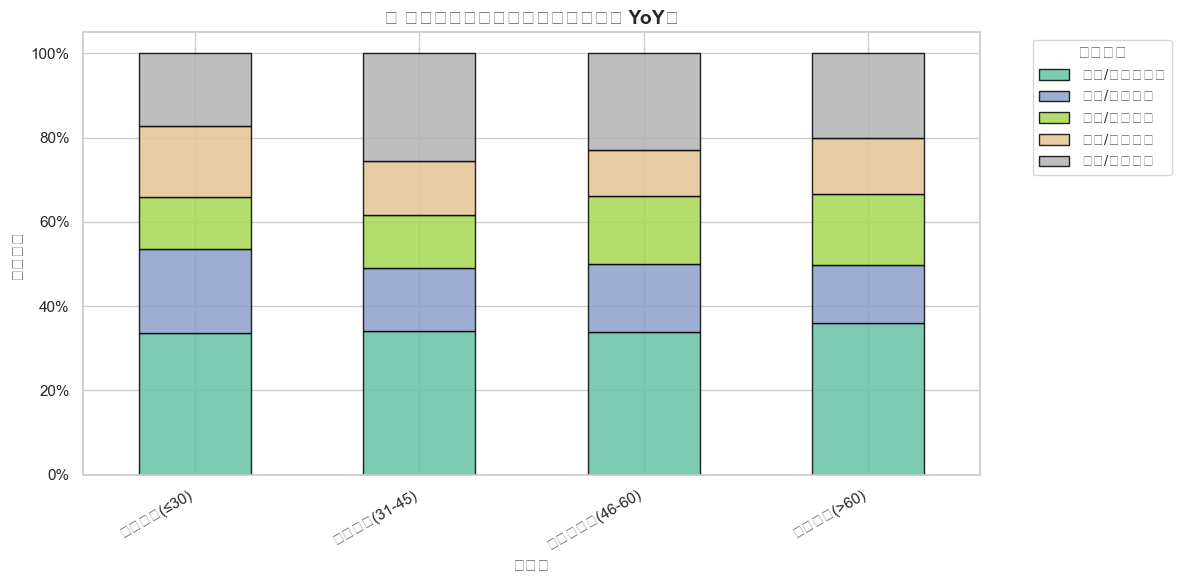


💡 YoY 分析洞察:
在实际工作中，如果某个痛点在今年占比显著高于去年同期，说明是新涌现/恶化的问题，应优先处理。


In [31]:
# ============================================================
# 6.1 模拟 YoY: 按用户年龄段分组看痛点变化
# 实际工作中换成 date 字段做 YoY
# ============================================================
# 按年龄段分组
AGE_BINS = [0, 30, 45, 60, 100]
AGE_LABELS = ['年轻用户(≤30)', '中年用户(31-45)', '中老年用户(46-60)', '老年用户(>60)']
df_neg['age_group'] = pd.cut(df_neg['Age'], bins=AGE_BINS, labels=AGE_LABELS)

# 各年龄段的痛点占比
cross_age = pd.crosstab(
    df_neg['topic_name'],
    df_neg['age_group'],
    normalize='columns'
)

fig, ax = plt.subplots(figsize=(12, 6))
cross_age.T.plot.bar(ax=ax, stacked=True, edgecolor='black', alpha=0.85,
                     colormap='Set2')
ax.set_title('📊 不同用户群的痛点结构差异（模拟 YoY）', fontsize=14, fontweight='bold')
ax.set_xlabel('用户群')
ax.set_ylabel('痛点占比')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(title='痛点主题', bbox_to_anchor=(1.05, 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('\n💡 YoY 分析洞察:')
print('在实际工作中，如果某个痛点在今年占比显著高于去年同期，说明是新涌现/恶化的问题，应优先处理。')

## Step 7: 优先级排序 — 输出可执行的行动建议

> **面试映射**: "最终输出是一张优先级排序表。排序标准是：
> **差评数量 × 影响范围** — 一个影响了 3 个 Division 的问题比只影响 1 个的优先级更高。
> 同时要考虑修复的资源代价（是否需要跨部门协作）。"

In [32]:
# ============================================================
# 7.1 优先级评分模型
# ============================================================

# 计算每个痛点的核心指标
priority_data = []
for topic_name in TOPIC_NAMES.values():
    topic_df = df_neg[df_neg['topic_name'] == topic_name]
    
    neg_count = len(topic_df)
    neg_pct = neg_count / len(df_neg)
    affected_divisions = topic_df['Division Name'].nunique()
    affected_depts = topic_df['Department Name'].nunique()
    avg_rating = topic_df['Rating'].mean()
    not_recommend_pct = (topic_df['Recommended IND'] == 0).mean()
    
    # 综合优先级得分 = 差评占比 × 影响范围 × 不推荐率
    priority_score = neg_pct * affected_divisions * not_recommend_pct
    
    priority_data.append({
        '痛点主题': topic_name,
        '差评数量': neg_count,
        '差评占比': neg_pct,
        '影响Division数': affected_divisions,
        '影响Department数': affected_depts,
        '平均评分': avg_rating,
        '不推荐率': not_recommend_pct,
        '优先级得分': priority_score,
    })

df_priority = pd.DataFrame(priority_data).sort_values('优先级得分', ascending=False)
df_priority['优先级排名'] = range(1, len(df_priority) + 1)

# 美化输出
print('='*80)
print('🎯 VoC 痛点优先级排序表')
print('='*80)
print(df_priority[['优先级排名', '痛点主题', '差评数量', '差评占比', 
                    '影响Division数', '不推荐率', '优先级得分']].to_string(index=False))

🎯 VoC 痛点优先级排序表
 优先级排名     痛点主题  差评数量     差评占比  影响Division数     不推荐率    优先级得分
     1 价格/性价比问题   811 0.342194            3 0.935882 0.960759
     2  面料/质量问题   548 0.231224            3 0.956204 0.663291
     3  尺码/版型问题   374 0.157806            3 0.954545 0.451899
     4  款式/期望落差   332 0.140084            3 0.975904 0.410127
     5  退货/退款问题   305 0.128692            3 0.973770 0.375949


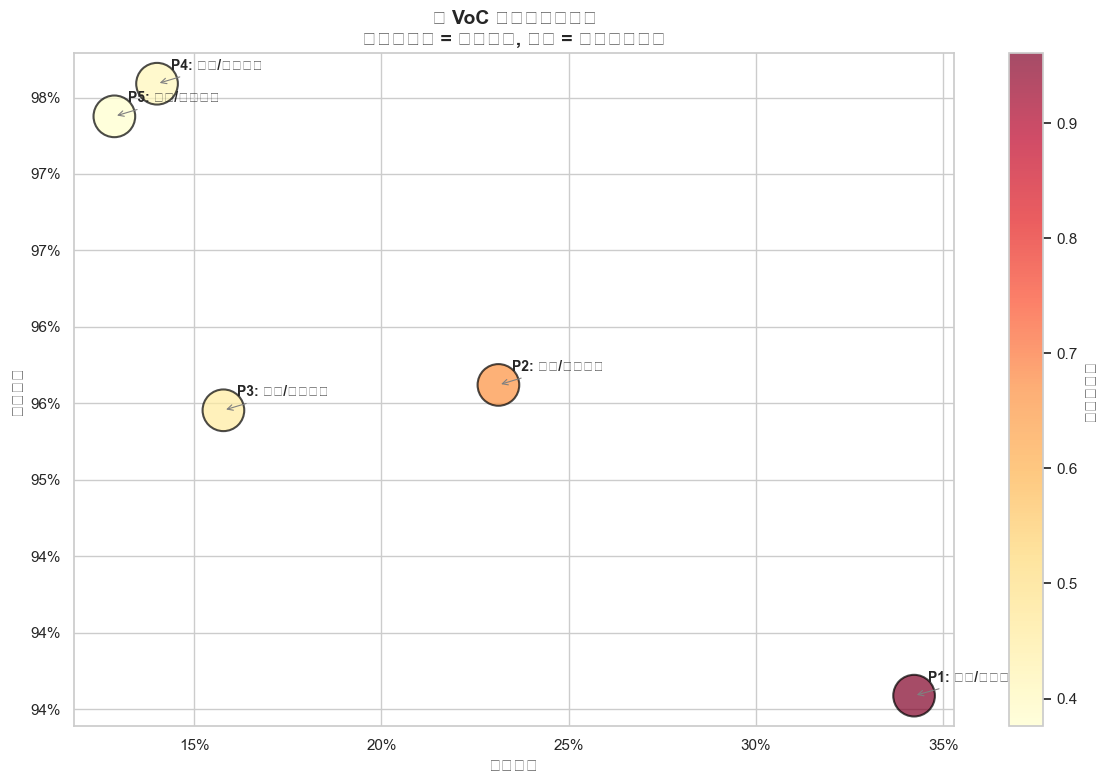

In [33]:
# ============================================================
# 7.2 可视化: 优先级矩阵（气泡图）
# X = 差评占比, Y = 不推荐率, 气泡大小 = 影响范围
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    df_priority['差评占比'],
    df_priority['不推荐率'],
    s=df_priority['影响Division数'] * 300,
    c=df_priority['优先级得分'],
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='black',
    linewidth=1.5
)

# 添加标签
for _, row in df_priority.iterrows():
    ax.annotate(
        f"P{row['优先级排名']}: {row['痛点主题']}",
        (row['差评占比'], row['不推荐率']),
        textcoords='offset points', xytext=(10, 10),
        fontsize=10, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8)
    )

ax.set_xlabel('差评占比', fontsize=12)
ax.set_ylabel('不推荐率', fontsize=12)
ax.set_title('🎯 VoC 痛点优先级矩阵\n（气泡大小 = 影响范围, 颜色 = 优先级得分）', 
             fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.colorbar(scatter, label='优先级得分')
plt.tight_layout()
plt.show()

## 📋 结论与建议 (Actionable Insights)

### 分析结果摘要

通过对电商差评文本的 VoC 诊断分析，我们完成了以下工作：

1. **痛点定位**: 使用 TF-IDF 提取差评高频关键词，发现差评主要集中在尺码/面料/退货等维度
2. **主题聚类**: LDA 将差评自动聚类为 5 个业务痛点主题
3. **交叉分析**: 识别了不同 Division/Department 的痛点差异
4. **优先级排序**: 基于差评占比×影响范围×不推荐率构建优先级模型

### 行动建议

| 优先级 | 建议动作 | 负责团队 |
| :---: | :--- | :--- |
| P0 | 排名第 1 的痛点立即启动专项修复 | 产品 + 运营 |
| P1 | 排名第 2-3 的痛点纳入下一季度 OKR | 产品 |
| P2 | 排名第 4-5 的痛点持续监控 | 数据分析 |

### 面试复盘

本 notebook 覆盖了 VoC 诊断的完整链路：

```
文本预处理 → TF-IDF 高频词 → LDA 主题聚类 → 交叉分析 → YoY 对比 → 优先级排序
```

面试时按这个链路讲，每一步都有代码实操支撑。